# **Exploración de los datos**
---

Este notebook realiza el análisis exploratorio inicial del dataset de IBM.

Objetivos:

1. Revisar la estructura general del dataset.
2. Validar tipos de datos y valores nulos.
3. Analizar la variable objetivo.
4. Explorar variables numéricas y categóricas.
5. Identificar patrones iniciales relacionados con fraude.
6. Terminar con las conclusiones para la fase de feature engineering.

## **1. Librerías**
---

In [2]:
# Importar librerías
import sys
from pathlib import Path

# Añadir el directorio raíz del proyecto al path de Python PRIMERO
proyecto_root = str(Path('.').resolve().parent)
if proyecto_root not in sys.path:
    sys.path.insert(0, proyecto_root)

import pandas as pd
import os
import argparse 
from datetime import datetime
from dateutil import parser
import matplotlib.pyplot as plt
import numpy as np

# Recargar módulo para obtener las funciones más recientes
import importlib
if 'src.data.funciones_parte_1' in sys.modules:
    importlib.reload(sys.modules['src.data.funciones_parte_1'])

from src.data.funciones_parte_1 import convertir_parquet, leer_parquet_si_existe
from src.utils.paths import get_transactions_parquet_path
from src.data.load_data import read_transactions_parquet, read_sample_from_parquet
from src.utils.eda import (
    get_dataset_shape,
    get_null_summary,
    get_target_distribution,
    get_numeric_summary,
    get_categorical_distribution,
    convert_data_types,
    impute_location_fields,
    get_unique_and_null_values_summary,
    finalize_transaction_columns
)

## **2. Análisis de la base de datos**
---

### **2.1 Cargue de la base de datos**
---

In [3]:
# Definir rutas relativas
ruta_csv = os.path.join(proyecto_root, 'data', 'original', 'card_transaction.csv')
ruta_parquet = os.path.join(proyecto_root, 'data', 'processed', 'card_transaction.parquet')

# Verificar si el archivo Parquet existe, si no, convertir
if not os.path.exists(ruta_parquet):
    print(f"Convirtiendo CSV a Parquet")
    convertir_parquet(ruta_csv, ruta_parquet, chunksize=2_000_000)
    print(f"Conversión completada\n")
else:
    print(f"Archivo ya existe, no necesito crearlo\n")

# Cargar el archivo Parquet
df_cards = pd.read_parquet(ruta_parquet)
print(f"Dimensiones del dataset: {df_cards.shape}")

Archivo ya existe, no necesito crearlo

Dimensiones del dataset: (24386900, 15)


In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
print(f"Ver DataFrame:")
pd.concat([df_cards.head(4), df_cards.tail(4)])

Ver DataFrame:


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
24386896,1999,1,2020,2,27,22:24,$54.00,Chip Transaction,-5162038175624867091,Merrimack,NH,3054.0,5541,NaN,No
24386897,1999,1,2020,2,28,07:43,$59.15,Chip Transaction,2500998799892805156,Merrimack,NH,3054.0,4121,NaN,No
24386898,1999,1,2020,2,28,20:10,$43.12,Chip Transaction,2500998799892805156,Merrimack,NH,3054.0,4121,NaN,No
24386899,1999,1,2020,2,28,23:10,$45.13,Chip Transaction,4751695835751691036,Merrimack,NH,3054.0,5814,NaN,No


In [5]:
# Leer si existe
df_cards = leer_parquet_si_existe(ruta_parquet)

Archivo cargado: C:\Users\cecor\OneDrive - Universidad Nacional de Colombia\GitHub\MSc-Thesis-Financial-Fraud-Detection-Models\data\processed\card_transaction.parquet
 Dimensiones: 24,386,900 filas × 15 columnas


### **2.2 Valores nulos y duplicados**
---

In [6]:
# Cambio el nombre de las columnas
df_cards.columns=df_cards.columns.str.strip().str.lower().str.replace(' ', '_')
df_cards.columns

Index(['user', 'card', 'year', 'month', 'day', 'time', 'amount', 'use_chip',
       'merchant_name', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors?', 'is_fraud?'],
      dtype='str')

In [7]:
df_cards.dtypes

user                int64
card                int64
year                int64
month               int64
day                 int64
time                  str
amount                str
use_chip              str
merchant_name       int64
merchant_city         str
merchant_state        str
zip               float64
mcc                 int64
errors?               str
is_fraud?             str
dtype: object

Algunas variables no tienen el tipo de variable deseado.

In [8]:
# Recargar el módulo eda para obtener la versión actualizada
import src.utils.eda
importlib.reload(src.utils.eda)
from src.utils.eda import convert_data_types

# Convertir variables a su tipo correcto
df_cards = convert_data_types(df_cards)
print("Tipos de datos después de conversión:")
print(df_cards.dtypes)

Tipos de datos después de conversión:
user               string
card               string
year                Int16
month               Int16
day                 Int16
time               string
amount            float64
use_chip           string
merchant_name      string
merchant_city      string
merchant_state     string
zip                string
mcc                string
errors?               str
is_fraud?             str
dtype: object


In [9]:
unique_and_null_values_summary = get_unique_and_null_values_summary(df_cards)
unique_and_null_values_summary

,column,dtype,unique_values,missing_values,missing_percentage
0,merchant_name,string,100343,0,0.0000
1,amount,float64,98952,0,0.0000
2,zip,string,27322,2878135,11.8020
3,merchant_city,string,13429,0,0.0000
4,user,string,2000,0,0.0000
5,time,string,1440,0,0.0000
6,merchant_state,string,224,2720821,11.1569
7,mcc,string,109,0,0.0000
8,day,Int16,31,0,0.0000
9,year,Int16,30,0,0.0000


In [10]:
null_summary = get_null_summary(df_cards)
null_summary

,column,null_count,null_percentage
0,errors?,23998469,98.41
1,zip,2878135,11.80
2,merchant_state,2720821,11.16
3,month,0,0.00
4,user,0,0.00
5,card,0,0.00
6,year,0,0.00
7,amount,0,0.00
8,time,0,0.00
9,day,0,0.00


In [11]:
df_cards = impute_location_fields(df_cards)

In [12]:
df_cards[df_cards["zip_was_missing"]==1].head(4)

,user,card,year,month,day,time,amount,use_chip,merchant_name,merchant_city,merchant_state,zip,mcc,errors?,is_fraud?,merchant_state_was_missing,zip_was_missing,merchant_state_imputed,zip_imputed
11,0,0,2002,9,5,20:41,53.91,Online Transaction,-9092677072201095172,ONLINE,<NA>,<NA>,4900,NaN,No,1,1,UNKNOWN,UNKNOWN
24,0,0,2002,9,9,20:02,144.90,Online Transaction,-8338381919281017248,ONLINE,<NA>,<NA>,4899,NaN,No,1,1,UNKNOWN,UNKNOWN
85,0,0,2002,9,30,06:21,127.32,Online Transaction,-7421093378627544099,ONLINE,<NA>,<NA>,5311,NaN,No,1,1,UNKNOWN,UNKNOWN
99,0,0,2002,10,6,06:14,139.39,Online Transaction,-7421093378627544099,ONLINE,<NA>,<NA>,5311,NaN,No,1,1,UNKNOWN,UNKNOWN


In [13]:
df_cards.columns

Index(['user', 'card', 'year', 'month', 'day', 'time', 'amount', 'use_chip',
       'merchant_name', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors?', 'is_fraud?', 'merchant_state_was_missing', 'zip_was_missing',
       'merchant_state_imputed', 'zip_imputed'],
      dtype='str')

In [14]:
df_cards["user_card_id"] = (
    df_cards["user"].astype("string") + "_" + df_cards["card"].astype("string"))

In [15]:
df_cards = finalize_transaction_columns(df_cards)

In [16]:
df_cards.head(4)

,user,card,year,month,day,time,amount,use_chip,merchant_name,merchant_city,merchant_state,zip,mcc,is_fraud?,merchant_state_was_missing,zip_was_missing,user_card_id
0,0,0,2002,9,1,06:21,134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750,5300,No,0,0,0_0
1,0,0,2002,9,1,06:42,38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,No,0,0,0_0
2,0,0,2002,9,2,06:22,120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,No,0,0,0_0
3,0,0,2002,9,2,17:45,128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754,5651,No,0,0,0_0


In [17]:
df_cards.rename(columns={'is_fraud?': 'is_fraud'}, inplace=True)
df_cards['is_fraud'] = df_cards['is_fraud'].map({'Yes': 1, 'No': 0}).astype('Int8')

### **2.3 Análisis de las variables**
---

#### **2.3.1 Variable objetivo**


La variable objetivo indica si una transacción fue fraudulenta o no. Esta sección permite medir el nivel de desbalance del problema.

In [18]:
TARGET_COL = "is_fraud"
target_distribution = get_target_distribution(df_cards, TARGET_COL)
target_distribution

,is_fraud,count,proportion
0,0,24357143,0.9988
1,1,29757,0.0012


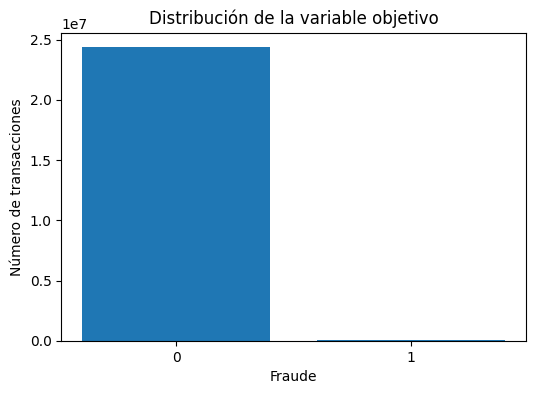

In [19]:
plt.figure(figsize=(6, 4))
plt.bar(
    target_distribution[TARGET_COL].astype(str),
    target_distribution["count"],
)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Fraude")
plt.ylabel("Número de transacciones")
plt.show()

La distribución de la variable objetivo permite confirmar el desbalance de clases. En detección de fraude, este punto es crítico porque la exactitud o accuracy puede ser engañosa.

In [20]:
df_cards.columns

Index(['user', 'card', 'year', 'month', 'day', 'time', 'amount', 'use_chip',
       'merchant_name', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'is_fraud', 'merchant_state_was_missing', 'zip_was_missing',
       'user_card_id'],
      dtype='str')

#### **2.3.2 Variable amount**


Se analiza la distribución de los montos transaccionales. En problemas de fraude, los montos pueden tener asimetría fuerte y valores extremos. La variable puede presentar valores negativos, que se pueden interpretar como reversas o ajustes transaccionales, por lo que no se consideran errores automáticamente. Se conserva el monto original con signo y se crean variables derivadas como `amount_is_negative` y `amount_abs` para capturar tanto la dirección como la magnitud del movimiento.

In [21]:
AMOUNT_COL = "amount"

In [22]:
amount_summary = get_numeric_summary(df_cards, [AMOUNT_COL])
amount_summary

,amount_mean,amount_median,amount_std,amount_min,amount_max
0,43.634005,30.14,82.02239,-500.0,12390.5


In [23]:
amount_by_target = (
    df_cards
    .groupby(TARGET_COL)[AMOUNT_COL]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)
amount_by_target

,is_fraud,count,mean,median,std,min,max
0,0,24357143,43.554648,30.11,81.739172,-500.0,12390.50
1,1,29757,108.590874,71.02,201.167421,-500.0,5694.44


In [24]:
amount_quantiles_by_target = (
    df_cards
    .groupby(TARGET_COL)[AMOUNT_COL]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .reset_index()
    .rename(columns={"level_1": "quantile", AMOUNT_COL: "amount"})
)
amount_quantiles_by_target

,is_fraud,quantile,amount
0,0,0.01,-96.0000
1,0,0.05,-51.0000
2,0,0.25,9.2000
3,0,0.50,30.1100
4,0,0.75,65.0000
5,0,0.95,146.4300
6,0,0.99,315.3500
7,1,0.01,-378.0000
8,1,0.05,0.2700
9,1,0.25,18.3600


<Figure size 700x400 with 0 Axes>

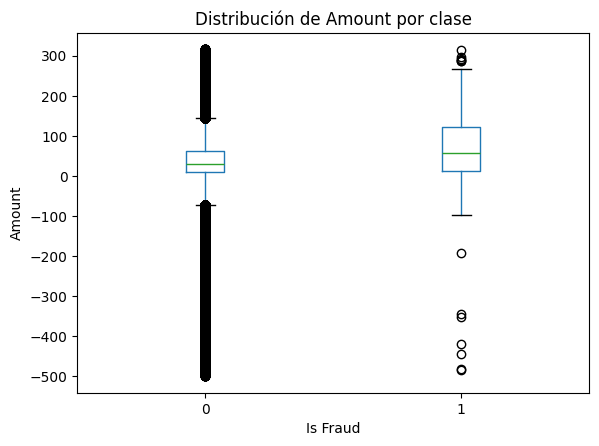

In [25]:
amount_p99 = df_cards[AMOUNT_COL].quantile(0.99)
amount_boxplot_sample = df_cards.loc[
    df_cards[AMOUNT_COL] <= amount_p99,
    [TARGET_COL, AMOUNT_COL]
].sample(
    n=min(200_000, len(df_cards)),
    random_state=42
)
plt.figure(figsize=(7, 4))
amount_boxplot_sample.boxplot(
    column=AMOUNT_COL,
    by=TARGET_COL,
    grid=False
)

plt.title("Distribución de Amount por clase")
plt.suptitle("")
plt.xlabel("Is Fraud")
plt.ylabel("Amount")
plt.show()

In [26]:
df_cards["amount_is_negative"] = (df_cards["amount"] < 0).astype("Int8")
df_cards["amount_abs"] = df_cards["amount"].abs()

#### **2.3.3 Variables de tiempo**

In [27]:
YEAR_COL = "year"
MONTH_COL = "month"
DAY_COL = "day"
TIME_COL = "time"

In [28]:
df_cards["hour"] = df_cards[TIME_COL].astype(str).str.slice(0, 2).astype(int)

df_cards[[TIME_COL, "hour"]].head()

,time,hour
0,06:21,6
1,06:42,6
2,06:22,6
3,17:45,17
4,06:23,6


In [29]:
df_cards["datetime"] = pd.to_datetime(
    df_cards[YEAR_COL].astype(str) + "-" +
    df_cards[MONTH_COL].astype(str).str.zfill(2) + "-" +
    df_cards[DAY_COL].astype(str).str.zfill(2) + " " +
    df_cards[TIME_COL].astype(str),
    errors="coerce"
)

df_cards[["datetime", YEAR_COL, MONTH_COL, DAY_COL, TIME_COL]].head()

,datetime,year,month,day,time
0,2002-09-01 06:21:00,2002,9,1,06:21
1,2002-09-01 06:42:00,2002,9,1,06:42
2,2002-09-02 06:22:00,2002,9,2,06:22
3,2002-09-02 17:45:00,2002,9,2,17:45
4,2002-09-03 06:23:00,2002,9,3,06:23


In [30]:
invalid_datetime_count = df_cards["datetime"].isna().sum()

print(f"Número de fechas inválidas: {invalid_datetime_count:,}")

Número de fechas inválidas: 0


In [31]:
df_cards["day_of_week"] = df_cards["datetime"].dt.dayofweek
df_cards["is_weekend"] = df_cards["day_of_week"].isin([5, 6]).astype(int)

df_cards[["datetime", "hour", "day_of_week", "is_weekend"]].head()

,datetime,hour,day_of_week,is_weekend
0,2002-09-01 06:21:00,6,6,1
1,2002-09-01 06:42:00,6,6,1
2,2002-09-02 06:22:00,6,0,0
3,2002-09-02 17:45:00,17,0,0
4,2002-09-03 06:23:00,6,1,0


In [32]:
df_cards["day_of_week"] = df_cards["datetime"].dt.dayofweek
df_cards["is_weekend"] = df_cards["day_of_week"].isin([5, 6]).astype(int)

df_cards[["datetime", "hour", "day_of_week", "is_weekend"]].head()

,datetime,hour,day_of_week,is_weekend
0,2002-09-01 06:21:00,6,6,1
1,2002-09-01 06:42:00,6,6,1
2,2002-09-02 06:22:00,6,0,0
3,2002-09-02 17:45:00,17,0,0
4,2002-09-03 06:23:00,6,1,0


In [33]:
fraud_by_year = (
    df_cards
    .groupby(YEAR_COL)
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
    .sort_values(YEAR_COL)
)

fraud_by_year

,year,count,fraud_count,fraud_rate
0,1991,1585,0,0.0
1,1992,5134,0,0.0
2,1993,8378,0,0.0
3,1994,14316,0,0.0
4,1995,20928,0,0.0
5,1996,29945,10,0.000334
6,1997,49753,32,0.000643
7,1998,78345,32,0.000408
8,1999,118250,24,0.000203
9,2000,177729,171,0.000962


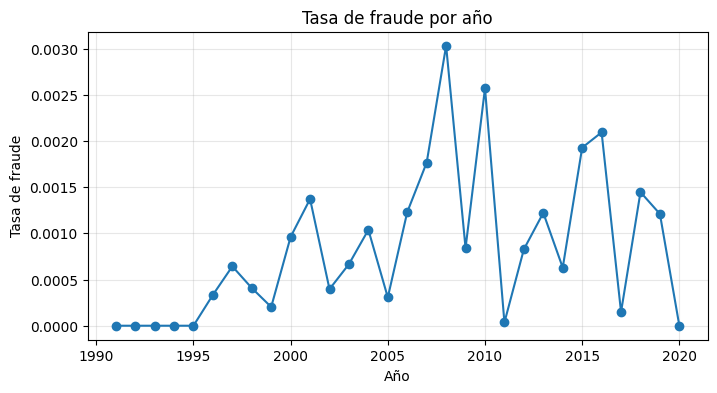

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(
    fraud_by_year[YEAR_COL],
    fraud_by_year["fraud_rate"],
    marker="o"
)
plt.title("Tasa de fraude por año")
plt.xlabel("Año")
plt.ylabel("Tasa de fraude")
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
fraud_by_month = (
    df_cards
    .groupby(MONTH_COL)
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
    .sort_values(MONTH_COL)
)
fraud_by_month

,month,count,fraud_count,fraud_rate
0,1,2142220,2302,0.001075
1,2,1960411,2320,0.001183
2,3,2002867,2608,0.001302
3,4,1941806,2430,0.001251
4,5,2023412,2481,0.001226
5,6,1981230,2166,0.001093
6,7,2051785,2332,0.001137
7,8,2070407,2721,0.001314
8,9,2006307,2373,0.001183
9,10,2075188,2666,0.001285


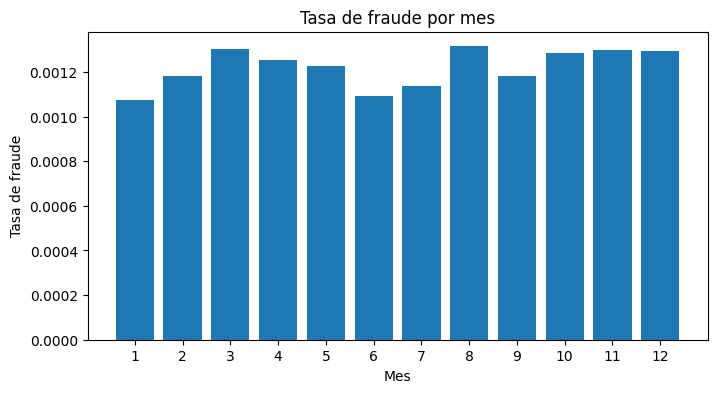

In [36]:
plt.figure(figsize=(8, 4))
plt.bar(
    fraud_by_month[MONTH_COL],
    fraud_by_month["fraud_rate"]
)
plt.title("Tasa de fraude por mes")
plt.xlabel("Mes")
plt.ylabel("Tasa de fraude")
plt.xticks(range(1, 13))
plt.show()

In [37]:
fraud_by_day = (
    df_cards
    .groupby(DAY_COL)
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
    .sort_values(DAY_COL)
)
fraud_by_day

,day,count,fraud_count,fraud_rate
0,1,810649,1023,0.001262
1,2,795655,1032,0.001297
2,3,799048,919,0.00115
3,4,805366,923,0.001146
4,5,796347,1063,0.001335
5,6,799532,1035,0.001295
6,7,810589,1086,0.00134
7,8,800735,937,0.00117
8,9,797145,877,0.0011
9,10,799448,897,0.001122


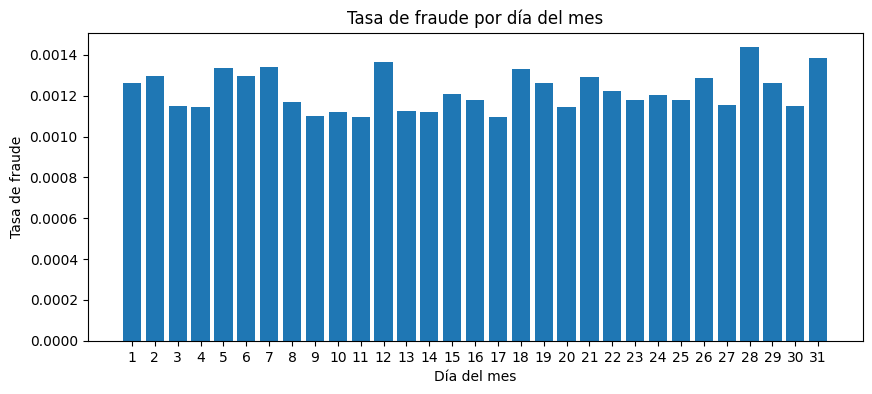

In [38]:
plt.figure(figsize=(10, 4))
plt.bar(
    fraud_by_day[DAY_COL],
    fraud_by_day["fraud_rate"]
)
plt.title("Tasa de fraude por día del mes")
plt.xlabel("Día del mes")
plt.ylabel("Tasa de fraude")
plt.xticks(range(1, 32))
plt.show()

In [39]:
fraud_by_hour = (
    df_cards
    .groupby("hour")
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
    .sort_values("hour")
)
fraud_by_hour

,hour,count,fraud_count,fraud_rate
0,0,235608,120,0.000509
1,1,213411,185,0.000867
2,2,214075,231,0.001079
3,3,183370,342,0.001865
4,4,203550,372,0.001828
5,5,321588,505,0.00157
6,6,1347058,855,0.000635
7,7,1644618,1597,0.000971
8,8,1616851,1674,0.001035
9,9,1598928,2178,0.001362


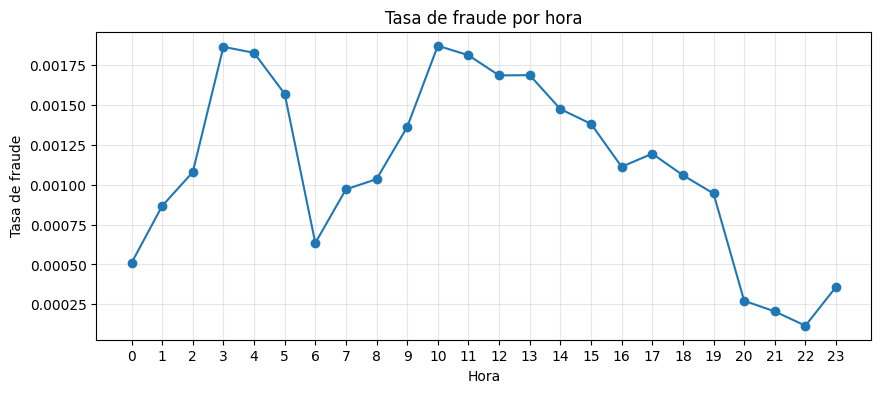

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(
    fraud_by_hour["hour"],
    fraud_by_hour["fraud_rate"],
    marker="o"
)
plt.title("Tasa de fraude por hora")
plt.xlabel("Hora")
plt.ylabel("Tasa de fraude")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
fraud_by_weekend = (
    df_cards
    .groupby("is_weekend")
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
)

fraud_by_weekend["period_type"] = fraud_by_weekend["is_weekend"].map({
    0: "Día hábil",
    1: "Fin de semana",
})
fraud_by_weekend

,is_weekend,count,fraud_count,fraud_rate,period_type
0,0,17402104,20836,0.001197,Día hábil
1,1,6984796,8921,0.001277,Fin de semana


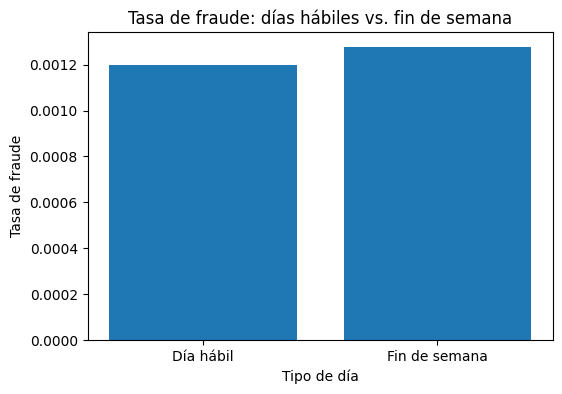

In [42]:
plt.figure(figsize=(6, 4))
plt.bar(
    fraud_by_weekend["period_type"],
    fraud_by_weekend["fraud_rate"]
)
plt.title("Tasa de fraude: días hábiles vs. fin de semana")
plt.xlabel("Tipo de día")
plt.ylabel("Tasa de fraude")
plt.show()

#### **2.3.4 Uso de la tarjeta**

En esta sección se evalúa la relación entre el método de uso de la tarjeta y la tasa de fraude.

In [43]:
USE_CHIP_COL = "use_chip"

In [44]:
use_chip_distribution = get_categorical_distribution(
    df_cards,
    column=USE_CHIP_COL,
    target_col=TARGET_COL,
    top_n=20,
)
use_chip_distribution

,use_chip,count,fraud_rate,fraud_count
0,Swipe Transaction,15386082,0.000427,6572
1,Chip Transaction,6287598,0.000769,4836
2,Online Transaction,2713220,0.006763,18349


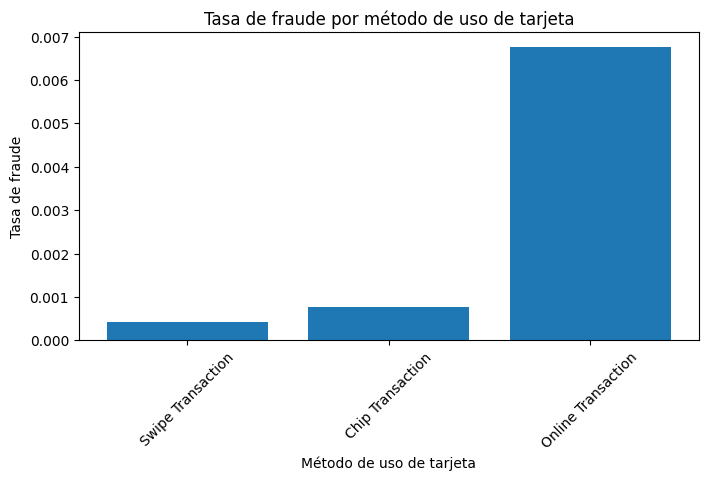

In [45]:
plt.figure(figsize=(8, 4))
plt.bar(
    use_chip_distribution[USE_CHIP_COL].astype(str),
    use_chip_distribution["fraud_rate"],
)
plt.title("Tasa de fraude por método de uso de tarjeta")
plt.xlabel("Método de uso de tarjeta")
plt.ylabel("Tasa de fraude")
plt.xticks(rotation=45)
plt.show()

#### **2.3.5 Compras por MCC**

El MCC corresponde al código de categoría del comercio. Esta variable puede capturar diferencias de riesgo entre tipos de establecimientos.

In [46]:
MCC_COL = "mcc"

mcc_distribution = get_categorical_distribution(
    df_cards,
    column=MCC_COL,
    target_col=TARGET_COL,
    top_n=20,
)
mcc_distribution

,mcc,count,fraud_rate,fraud_count
0,5411,2860738,0.00033,943
1,5499,2680609,0.000097,260
2,5541,2638982,0.000134,354
3,5812,1797920,0.000182,327
4,5912,1407636,0.000751,1057
5,4829,1129061,0.001423,1607
6,4784,1124291,0.0,0
7,5300,1123037,0.00196,2201
8,4121,981523,0.000569,558
9,7538,914630,0.000056,51


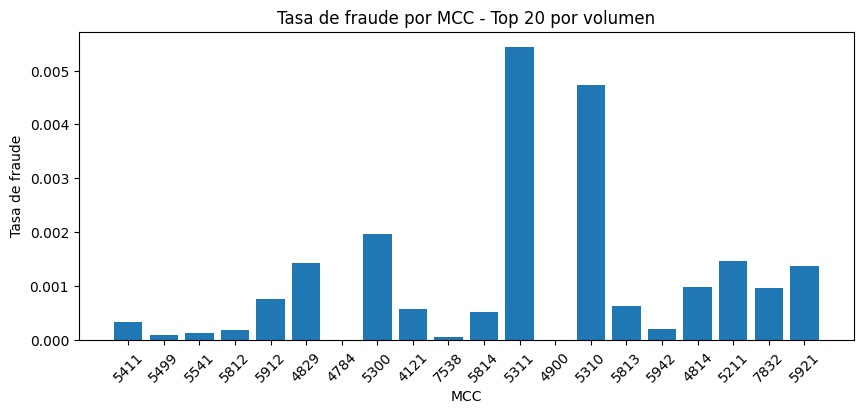

In [47]:
plt.figure(figsize=(10, 4))
plt.bar(
    mcc_distribution[MCC_COL].astype(str),
    mcc_distribution["fraud_rate"]
)
plt.title("Tasa de fraude por MCC - Top 20 por volumen")
plt.xlabel("MCC")
plt.ylabel("Tasa de fraude")
plt.xticks(rotation=45)
plt.show()

In [48]:
mcc_risk = (
    df_cards
    .groupby(MCC_COL)
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
)

mcc_risk_filtered = (
    mcc_risk
    .loc[mcc_risk["count"] >= 1_000]
    .sort_values("fraud_rate", ascending=False)
    .head(20)
)

mcc_risk_filtered

,mcc,count,fraud_count,fraud_rate
46,5045,5013,470,0.093756
67,5732,12593,843,0.066942
47,5094,9444,567,0.060038
73,5816,5003,298,0.059564
64,5712,7149,418,0.05847
34,4112,4151,159,0.038304
58,5533,2198,59,0.026843
36,4131,4108,80,0.019474
77,5941,2163,41,0.018955
39,4511,4688,85,0.018131


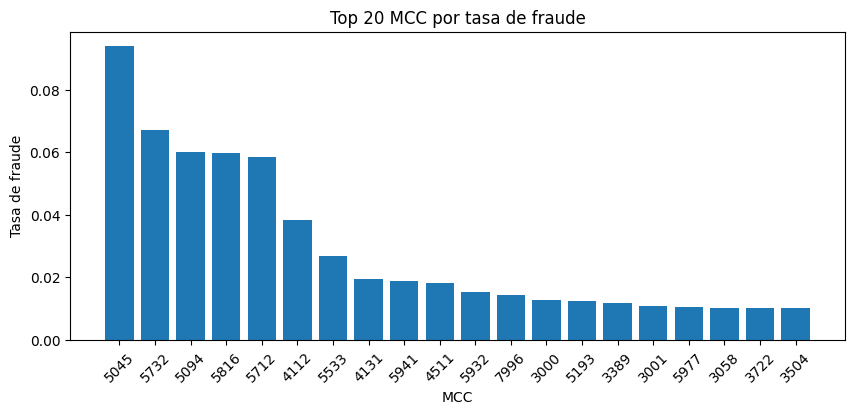

In [49]:
plt.figure(figsize=(10, 4))
plt.bar(
    mcc_risk_filtered[MCC_COL].astype(str),
    mcc_risk_filtered["fraud_rate"]
)
plt.title("Top 20 MCC por tasa de fraude")
plt.xlabel("MCC")
plt.ylabel("Tasa de fraude")
plt.xticks(rotation=45)
plt.show()

#### **2.3.6 Ubicación del comercio**


La ubicación del comercio puede ser útil para detectar patrones de riesgo, pero debe tratarse con cuidado debido a la alta cardinalidad de ciudades y estados. Para la fase de modelado inicial se priorizará `merchant_state`, mientras que `merchant_city` podría requerir agrupación, codificación por frecuencia o target encoding controlado para evitar sobreajuste.

In [50]:
MERCHANT_STATE_COL = "merchant_state"
MERCHANT_CITY_COL = "merchant_city"

In [51]:
merchant_state_distribution = get_categorical_distribution(
    df_cards,
    column="merchant_state",
    target_col=TARGET_COL,
    top_n=20,
)

merchant_state_distribution

,merchant_state,count,fraud_rate,fraud_count
0,UNKNOWN,2720821,0.006744,18349
1,CA,2591830,0.00029,751
2,TX,1793298,0.00017,305
3,FL,1458699,0.000215,314
4,NY,1446864,0.000166,240
5,OH,895970,0.00098,878
6,IL,850074,0.000134,114
7,PA,839647,0.000172,144
8,NC,779234,0.000185,144
9,GA,638884,0.000157,100


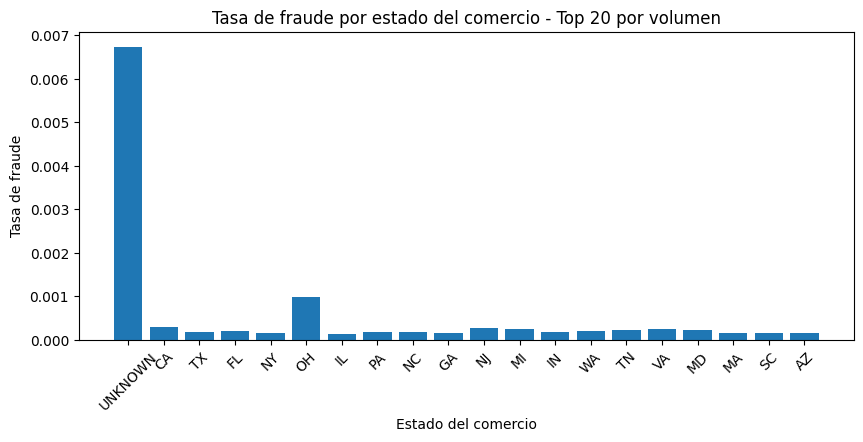

In [52]:
plt.figure(figsize=(10, 4))
plt.bar(
    merchant_state_distribution["merchant_state"].astype(str),
    merchant_state_distribution["fraud_rate"]
)
plt.title("Tasa de fraude por estado del comercio - Top 20 por volumen")
plt.xlabel("Estado del comercio")
plt.ylabel("Tasa de fraude")
plt.xticks(rotation=45)
plt.show()

In [53]:
state_risk = (
    df_cards
    .groupby("merchant_state")
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )    .reset_index())

state_risk_filtered = (
    state_risk
    .loc[state_risk["count"] >= 1_000]
    .sort_values("fraud_rate", ascending=False)
    .head(20))
state_risk_filtered

,merchant_state,count,fraud_count,fraud_rate
89,Italy,8730,4682,0.536312
91,Japan,3955,49,0.012389
203,UNKNOWN,2720821,18349,0.006744
122,Mexico,47152,272,0.005769
83,India,3482,5,0.001436
146,OH,895970,878,0.00098
1,AK,18301,8,0.000437
133,NE,96747,32,0.000331
73,HI,140180,46,0.000328
28,CA,2591830,751,0.00029


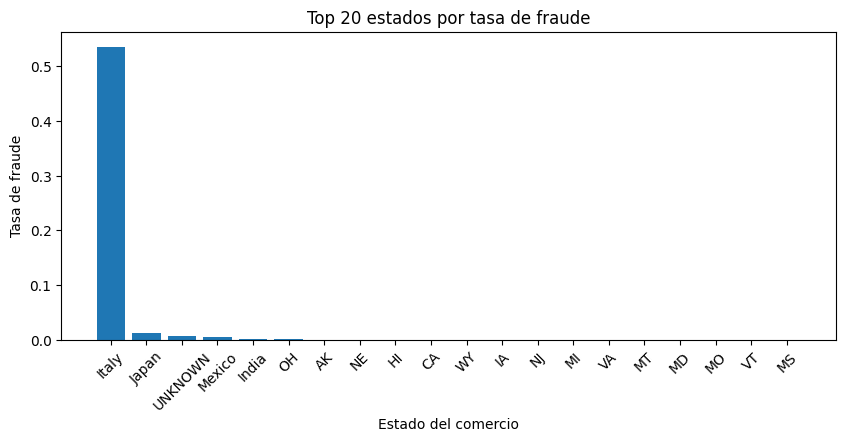

In [55]:
plt.figure(figsize=(10, 4))
plt.bar(
    state_risk_filtered["merchant_state"].astype(str),
    state_risk_filtered["fraud_rate"]
)
plt.title("Top 20 estados por tasa de fraude")
plt.xlabel("Estado del comercio")
plt.ylabel("Tasa de fraude")
plt.xticks(rotation=45)
plt.show()

#### **2.3.7 Número de tarjetas**

La variable `card` representa el número de tarjeta asociado a un usuario. En este dataset, sus valores van de 1 a 9, por lo que puede interpretarse como una variable discreta que identifica cuántas tarjetas tiene o usa una persona dentro del conjunto de datos.

En esta sección se analiza la distribución de transacciones y fraude según el número de tarjeta.

In [57]:
CARD_COL = "card"

In [59]:
fraud_by_card_number = (
    df_cards
    .groupby(CARD_COL)
    .agg(
        count=(TARGET_COL, "size"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean"),
    )
    .reset_index()
    .sort_values(CARD_COL))
fraud_by_card_number

,card,count,fraud_count,fraud_rate
0,0,8696411,8644,0.000994
1,1,6493597,7514,0.001157
2,2,4305594,5807,0.001349
3,3,2790785,4135,0.001482
4,4,1309120,2157,0.001648
5,5,563097,1016,0.001804
6,6,176729,350,0.00198
7,7,46383,109,0.00235
8,8,5184,25,0.004823


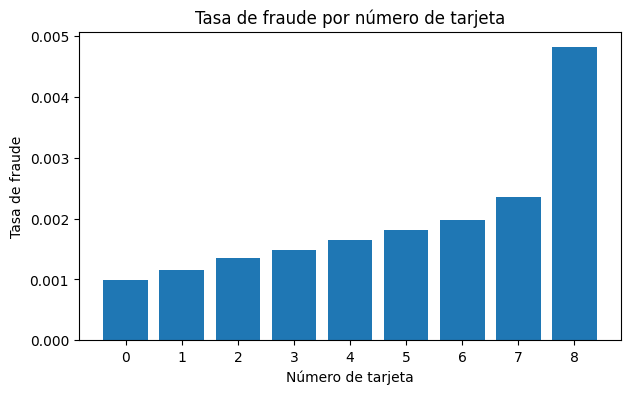

In [60]:
plt.figure(figsize=(7, 4))
plt.bar(
    fraud_by_card_number[CARD_COL].astype(str),
    fraud_by_card_number["fraud_rate"])
plt.title("Tasa de fraude por número de tarjeta")
plt.xlabel("Número de tarjeta")
plt.ylabel("Tasa de fraude")
plt.show()

In [61]:
df_cards.head(40)

,user,card,year,month,day,time,amount,use_chip,merchant_name,merchant_city,merchant_state,zip,mcc,is_fraud,merchant_state_was_missing,zip_was_missing,user_card_id,amount_is_negative,amount_abs,hour,datetime,day_of_week,is_weekend
0,0,0,2002,9,1,06:21,134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750,5300,0,0,0,0_0,0,134.09,6,2002-09-01 06:21:00,6,1
1,0,0,2002,9,1,06:42,38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,0,0,0,0_0,0,38.48,6,2002-09-01 06:42:00,6,1
2,0,0,2002,9,2,06:22,120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,0,0,0,0_0,0,120.34,6,2002-09-02 06:22:00,0,0
3,0,0,2002,9,2,17:45,128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754,5651,0,0,0,0_0,0,128.95,17,2002-09-02 17:45:00,0,0
4,0,0,2002,9,3,06:23,104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750,5912,0,0,0,0_0,0,104.71,6,2002-09-03 06:23:00,1,0
5,0,0,2002,9,3,13:53,86.19,Swipe Transaction,-7146670748125200898,Monterey Park,CA,91755,5970,0,0,0,0_0,0,86.19,13,2002-09-03 13:53:00,1,0
6,0,0,2002,9,4,05:51,93.84,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,0,0,0,0_0,0,93.84,5,2002-09-04 05:51:00,2,0
7,0,0,2002,9,4,06:09,123.50,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,0,0,0,0_0,0,123.50,6,2002-09-04 06:09:00,2,0
8,0,0,2002,9,5,06:14,61.72,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754,5411,0,0,0,0_0,0,61.72,6,2002-09-05 06:14:00,3,0
9,0,0,2002,9,5,09:35,57.10,Swipe Transaction,4055257078481058705,La Verne,CA,91750,7538,0,0,0,0_0,0,57.10,9,2002-09-05 09:35:00,3,0
